In [ ]:
# Import necessary libraries for the project
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import flask

# Verify PyTorch installation
print(f"Libraries loaded successfully. PyTorch version: {torch.__version__}")

Libraries loaded successfully. PyTorch version: 2.12.1+cpu


[*********************100%***********************]  1 of 1 completed

Fetching historical data for MSFT...

Data successfully loaded ! Here are the first 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2014-01-02,30.694441,30.892684,30.644879,30.851381,30632200
2014-01-03,30.487936,30.743999,30.231873,30.727479,31134800
2014-01-06,29.843649,30.471413,29.827128,30.438372,43603700
2014-01-07,30.074932,30.141014,29.909730,30.008853,35802800
2014-01-08,29.538034,29.851918,29.389356,29.736278,59971700


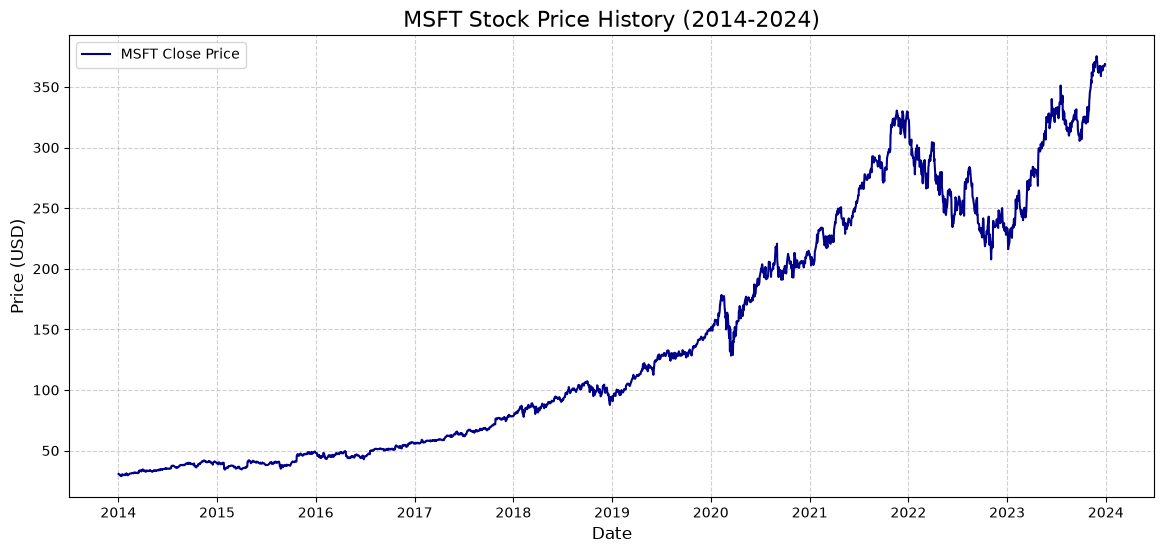

In [15]:
# 1. Define the stock ticker and the time range
ticker = 'MSFT'


start_date = '2014-01-01'
end_date = '2024-01-01'

# 2. Download the data using yfinance API
print(f"Fetching historical data for {ticker}...")
data = yf.download(ticker, start = start_date, end = end_date)

# 3. View the structure of our data
print("\nData successfully loaded ! Here are the first 5 rows:"),
# display() : html format / a table
display(data.head()) 

# 4. Visualize the 'Close' price to understand the historical trend
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label=f'{ticker} Close Price', color ='darkblue')

plt.title(f"{ticker} Stock Price History (2014-2024)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



In [16]:
# 1. Extract only the 'Close' column and convert it to a 2D NumPy array
prices = data[['Close']].values

# 2. Initialize the scaler to compress data between -1 and 1

scaler = MinMaxScaler(feature_range=(-1,1))

scaled_data = scaler.fit_transform(prices)

# 4. Verify the scaling process

print("--- Scaling Process Successful! ---")
print(f"Original Minimum Price: {prices.min():.2f} USD | Original Maximum Price:{prices.max():.2f} USD")
print(f"Scaled Min Value: {scaled_data.min():.2f} | Scaled Max Value: {scaled_data.max():.2f}\n")

print("First 5 days of scaled data:")
print(scaled_data[:5])

--- Scaling Process Successful! ---
Original Minimum Price: 28.89 USD | Original Maximum Price:375.41 USD
Scaled Min Value: -1.00 | Scaled Max Value: 1.00

First 5 days of scaled data:
[[-0.98960675]
 [-0.99079865]
 [-0.99451735]
 [-0.99318243]
 [-0.99628129]]


In [17]:
import numpy as np

def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        window = data[i:(i + window_size)]
        target = data[i + window_size]

        X.append(window)
        y.append(target)

    return np.array(X), np.array(y)

WINDOW_SIZE = 20
X, y = create_sequences(scaled_data, WINDOW_SIZE)

print("--- Sequence Creation Successful! ---")
print(f"Total sequences created: {len(X)}")
print(f"Shape of X (Inputs): {X.shape} -> (Total Samples, Window Size, Features)")
print(f"Shape of y (Targets): {y.shape} -> (Total Samples, Features)")

--- Sequence Creation Successful! ---
Total sequences created: 2496
Shape of X (Inputs): (2496, 20, 1) -> (Total Samples, Window Size, Features)
Shape of y (Targets): (2496, 1) -> (Total Samples, Features)


In [18]:
# 1. Find the index that splits the data at %80
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

# 2. Split the data chronologically

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

# 3. Verify the split
print("--- Train/Test Split Successful! ---")
print(f"Training sequences (X_train): {len(X_train)}")
print(f"Testing sequences (X_test): {len(X_test)}")

--- Train/Test Split Successful! ---
Training sequences (X_train): 1996
Testing sequences (X_test): 500


In [19]:
X_train_tensor = torch.tensor(X_train, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.float32)

X_test_tensor = torch.tensor(X_test, dtype= torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.float32)

# Verify the shape and data type of the created tensors
print("--- Tensor Conversion Successful! ---")
print(f"X_train Tensor Shape: {X_train_tensor.shape} | Data Type: {X_train_tensor.dtype}")
print(f"y_train Tensor Shape: {y_train_tensor.shape} | Data Type: {y_train_tensor.dtype}")
print(f"X_test Tensor Shape: {X_test_tensor.shape} | Data Type: {X_test_tensor.dtype}")
print(f"y_test Tensor Shape: {y_test_tensor.shape} | Data Type: {y_test_tensor.dtype}")

--- Tensor Conversion Successful! ---
X_train Tensor Shape: torch.Size([1996, 20, 1]) | Data Type: torch.float32
y_train Tensor Shape: torch.Size([1996, 1]) | Data Type: torch.float32
X_test Tensor Shape: torch.Size([500, 20, 1]) | Data Type: torch.float32
y_test Tensor Shape: torch.Size([500, 1]) | Data Type: torch.float32


In [20]:
# 1. Define the LSTM Model Architecture

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__() # Inherit from PyTorch base module

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        self.fc= nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))

        out = self.fc(out[:, -1, :])

        return out

print("--- Model Initialization ---")
model_lstm = LSTMModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1)
print(model_lstm)
    



--- Model Initialization ---
LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [21]:
# 1. Re-initialize the model with a BIGGER brain (hidden_dim: 32 -> 64)
model_lstm = LSTMModel(input_dim=1, hidden_dim=64, num_layers=2, output_dim=1)

# 2. Re-initialize the Loss and Optimizer
criterion = nn.MSELoss()
# Let's keep the learning rate the same
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# 3. Increase training time (num_epochs: 100 -> 250)
num_epochs = 250

print("--- Retraining Started with Upgraded Parameters ---")

for epoch in range(num_epochs):
    model_lstm.train() 
    
    outputs = model_lstm(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print progress every 25 epochs
    if (epoch + 1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')
        
print("--- Retraining Finished! ---")

--- Retraining Started with Upgraded Parameters ---
Epoch [25/250], Loss: 0.108560
Epoch [50/250], Loss: 0.019326
Epoch [75/250], Loss: 0.000991
Epoch [100/250], Loss: 0.000706
Epoch [125/250], Loss: 0.000560
Epoch [150/250], Loss: 0.000520
Epoch [175/250], Loss: 0.000509
Epoch [200/250], Loss: 0.000503
Epoch [225/250], Loss: 0.000498
Epoch [250/250], Loss: 0.000493
--- Retraining Finished! ---


In [22]:
# Set the model to evaluation mode
model_lstm.eval()

# Disable gradient calculation to save memory and computation during inference
with torch.no_grad():
    # Get predictions for both training and testing data
    train_predictions = model_lstm(X_train_tensor).numpy()
    test_predictions = model_lstm(X_test_tensor).numpy()

# Inverse transform the predictions and actuals from [-1, 1] back to original USD values
train_predictions_usd = scaler.inverse_transform(train_predictions)
y_train_usd = scaler.inverse_transform(y_train_tensor.numpy())

test_predictions_usd = scaler.inverse_transform(test_predictions)
y_test_usd = scaler.inverse_transform(y_test_tensor.numpy())

# Verify the predictions
print("--- Predictions Completed! ---")
print(f"First Test Day Actual Price: {y_test_usd[0][0]:.2f} USD")
print(f"First Test Day Predicted Price: {test_predictions_usd[0][0]:.2f} USD")

--- Predictions Completed! ---
First Test Day Actual Price: 316.93 USD
First Test Day Predicted Price: 324.72 USD


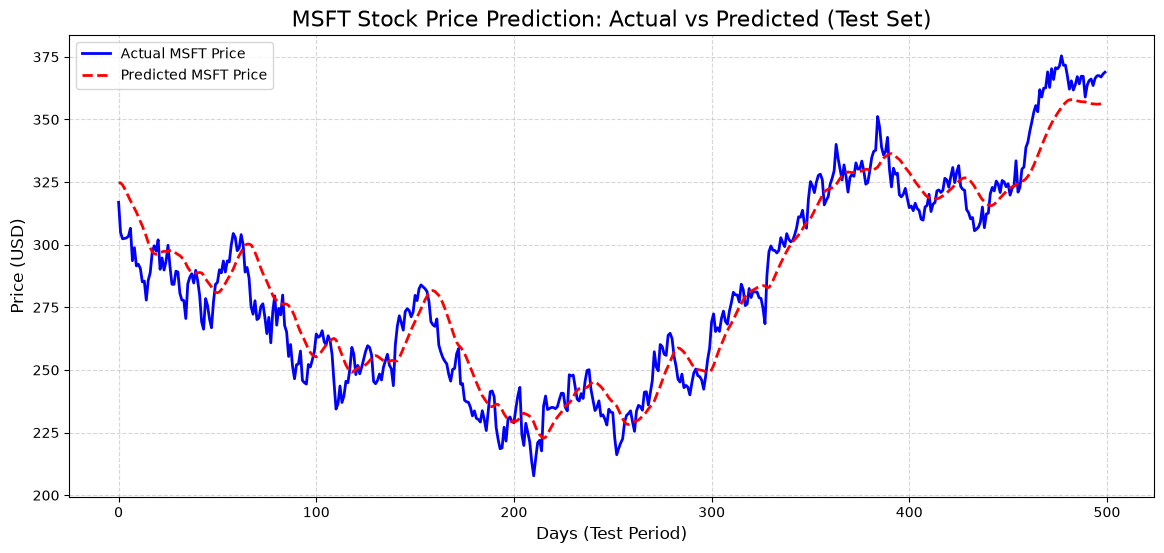

In [23]:
import matplotlib.pyplot as plt

# Plotting the Actual vs Predicted Prices for the Test Set
plt.figure(figsize=(14, 6))

# Plot the real prices in blue
plt.plot(y_test_usd, color = 'blue', label = f'Actual {ticker} Price', linewidth=2)

# Plot the model's predictions in red
plt.plot(test_predictions_usd, color = 'red', label = f'Predicted {ticker} Price', linestyle='dashed', linewidth=2)

# Professional formatting
plt.title(f'{ticker} Stock Price Prediction: Actual vs Predicted (Test Set)', fontsize = 16)
plt.xlabel('Days (Test Period)', fontsize=12)
plt.ylabel('Price (USD)', fontsize = 12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [24]:
import torch
import pickle

# 1. Save the PyTorch model weights (The Brain)
# It is a PyTorch best practice to save ONLY the weights(state_dict), not the entire class structure

model_path = f'{ticker}_lstm_model.pth'
torch.save(model_lstm.state_dict(), model_path)

# 2. Save the MinMaxScaler
# We must save the exact scaler fitted on MSFT data to decode future predictions
scaler_path = f'{ticker}_scaler.pkl'
with open(scaler_path, 'wb') as file:
    pickle.dump(scaler, file)

# Verify saving process
print("--- Checkpoint Saved Successfully! ---")
print(f"Model weights saved to: {model_path}")
print(f"Scaler object saved to: {scaler_path}")

--- Checkpoint Saved Successfully! ---
Model weights saved to: MSFT_lstm_model.pth
Scaler object saved to: MSFT_scaler.pkl


In [25]:
model_lstm.eval()

current_sequence = X_test_tensor[-1].unsqueeze(0)

future_predictions = []

with torch.no_grad():
    for _ in range(30):
        
        next_day_pred = model_lstm(current_sequence)

        future_predictions.append(next_day_pred.item())

        new_value = next_day_pred.unsqueeze(2)

        current_sequence = torch.cat((current_sequence[:, 1:, :], new_value), dim = 1)

future_predictions_usd = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

print("--- 30-Day Future Forecast Completed! ---")
for i, price in enumerate(future_predictions_usd):
    print(f"Day +{i+1}: {price[0]:.2f} USD")


--- 30-Day Future Forecast Completed! ---
Day +1: 356.45 USD
Day +2: 356.19 USD
Day +3: 355.72 USD
Day +4: 355.16 USD
Day +5: 354.52 USD
Day +6: 353.87 USD
Day +7: 353.21 USD
Day +8: 352.54 USD
Day +9: 351.90 USD
Day +10: 351.25 USD
Day +11: 350.63 USD
Day +12: 350.06 USD
Day +13: 349.48 USD
Day +14: 348.91 USD
Day +15: 348.36 USD
Day +16: 347.84 USD
Day +17: 347.31 USD
Day +18: 346.80 USD
Day +19: 346.31 USD
Day +20: 345.84 USD
Day +21: 345.38 USD
Day +22: 345.00 USD
Day +23: 344.62 USD
Day +24: 344.25 USD
Day +25: 343.89 USD
Day +26: 343.55 USD
Day +27: 343.22 USD
Day +28: 342.90 USD
Day +29: 342.59 USD
Day +30: 342.29 USD


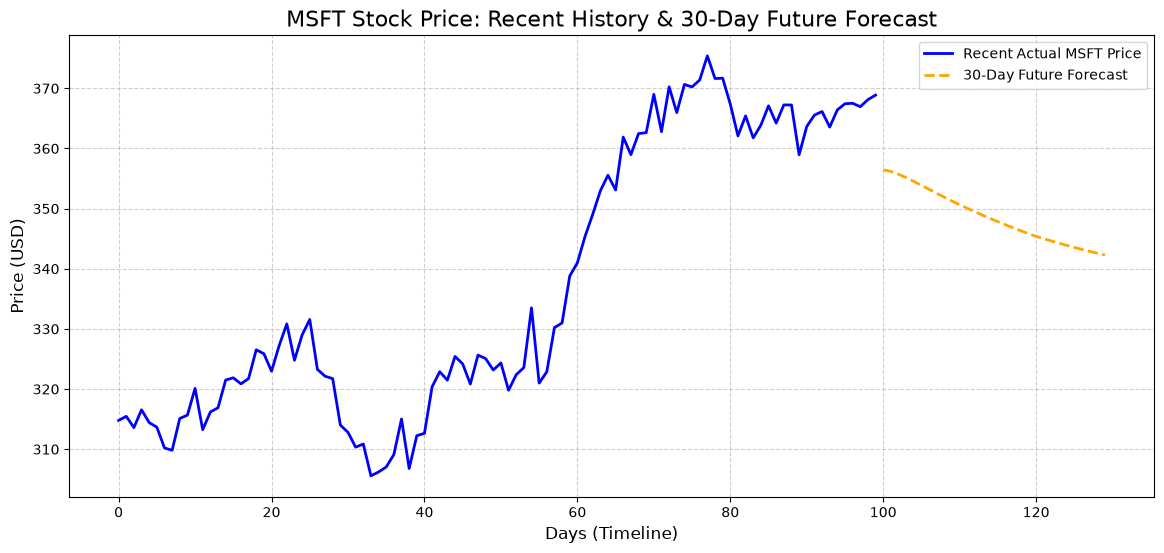

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Let's take the last 100 days of actual test data so the chart is easy to read
historical_data = y_test_usd[-100:] 

# Create the x-axis points for the future 30 days
last_day_index = len(historical_data)
future_days = np.arange(last_day_index, last_day_index + 30)

plt.figure(figsize=(14, 6))

# Plot the recent 100 days of actual history in blue
plt.plot(range(last_day_index), historical_data, color='blue', label='Recent Actual MSFT Price', linewidth=2)

# Plot the 30-day future forecast in orange, continuing from the last point
plt.plot(future_days, future_predictions_usd, color='orange', label='30-Day Future Forecast', linestyle='dashed', linewidth=2)

# Professional formatting
plt.title('MSFT Stock Price: Recent History & 30-Day Future Forecast', fontsize=16)
plt.xlabel('Days (Timeline)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [27]:
from flask import Flask, jsonify
import torch
import torch.nn as nn
import pickle
import numpy as np
import yfinance as yf

# 1. Start the Web Server
app = Flask(__name__)

# 2. Define the Neural Network Architecture (Required to load the brain)
class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, output_dim=1):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

# 3. Load the Saved Brain and Translator
model = LSTMModel()
model.load_state_dict(torch.load('msft_lstm_model.pth'))
model.eval()

with open('msft_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 4. Create the API Endpoint
@app.route('/predict', methods=['GET'])
def predict_tomorrow():
    try:
        # Fetch the real-time last 20 days of MSFT
        data = yf.download('MSFT', period='1mo')
        last_20_days = data['Close'].values[-20:].reshape(-1, 1)
        
        # Translate to [-1, 1] and convert to PyTorch Tensor
        scaled_data = scaler.transform(last_20_days)
        tensor_data = torch.FloatTensor(scaled_data).unsqueeze(0)
        
        # Make Prediction
        with torch.no_grad():
            prediction = model(tensor_data).numpy()
            
        # Translate back to USD
        predicted_price = scaler.inverse_transform(prediction)[0][0]
        
        return jsonify({
            "status": "success",
            "stock": "MSFT",
            "predicted_price_usd": round(float(predicted_price), 2)
        })
        
    except Exception as e:
        return jsonify({"status": "error", "message": str(e)})

# 5. Run the Server
if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)

ModuleNotFoundError: No module named 'flask'